# AI Agent Workshop - Day 1 
## Introduction to Agentified AI/ML Applications with the Google Gemini Stack

## How to use this notebook

This notebook is designed to be explored in sequence:

1. Read the concept sections.
2. Run the visualization cells.
3. Inspect and modify the code examples.
4. Discuss how each design pattern maps to the Day 2 challenge.

Throughout the notebook, we move from:

**LLM application → tool-using system → agentic workflow → deployable AI/ML application**

## Learning goals

By the end of this notebook, students should be able to:

- explain what makes an application *agentified* rather than just *prompt-based*,
- identify core design patterns for AI/ML agents,
- map those patterns onto the Google Gemini ecosystem,
- prototype a simple tool-using agent,
- reason about evaluation, safety, observability, and deployment trade-offs,
- prepare to extend an agentic application into a reproducible ML pipeline later using DVC.

## Why “agentified” AI/ML applications?

A traditional ML application often follows a relatively fixed path:

> input → feature processing → model inference → output

An **agentified** application still uses models, but adds a new capability:

> the system can decide *what to do next*.

That usually means some combination of:

- selecting tools,
- retrieving external knowledge,
- decomposing tasks,
- checking its own outputs,
- maintaining state across steps,
- deciding when to ask for clarification,
- deciding when to stop.

This makes agentified systems especially useful for **messy, real-world tasks** where a single model call is not enough.

### 🎯 Use Case: Improvements to Garbage Collection Services

The challenge is to build an AI‑powered assistant that helps residents understand which level of government (City, Region, Province, or Federal) is responsible for a service and guides them through the correct next steps. Example Questions are: 

> “Who do I contact about garbage pickup?”

A plain chatbot might answer:

> “Garbage pickup is usually handled by your municipality.”

An agentified civic assistant might instead:

1. inspect the question,
2. determine whether the service is municipal, regional, provincial, or federal,
3. consult trusted service sources,
4. cite the relevant jurisdiction,
5. recommend the next action,
6. optionally generate a resident-friendly response in plain language.

That is a much more realistic AI/ML application.

In [ ]:

# Optional setup for the notebook examples.
# Uncomment when running in a fresh environment.

# %pip install -q -U google-genai pandas matplotlib networkx python-dotenv

## The Google Gemini stack: a practical mental model

For teaching purposes, it helps to separate the stack into layers.

### 🧱 Software Stack Layer 1 — Models
Gemini models handle reasoning, generation, multimodal understanding, and long-context processing.

### 🧱 Software Stack Layer 2 — APIs and SDKs
The Google Gen AI SDK gives you a Python-first developer interface for calling Gemini models.

### 🧱 Software Stack Layer 3 — Tools
The model can use tools such as:
- custom function calls,
- retrieval / file search,
- search and URL-based grounding,
- code execution,
- maps or domain-specific tools where available.

### 🧱 Software Stack Layer 4 — Agent frameworks
When your workflow becomes more than “one model call,” frameworks such as **ADK** help structure agent behavior.

### 🧱 Software Stack Layer 5 — Production infrastructure
For deployment, scaling, sessions, memory, evaluation, and observability, the broader Vertex AI stack becomes relevant.

---

### 📌 Learning rule of thumb

Students should learn the stack in this order:

1. **Prompting and outputs**
2. **Tool use**
3. **Stateful workflows**
4. **Multi-step agents**
5. **Evaluation and deployment**

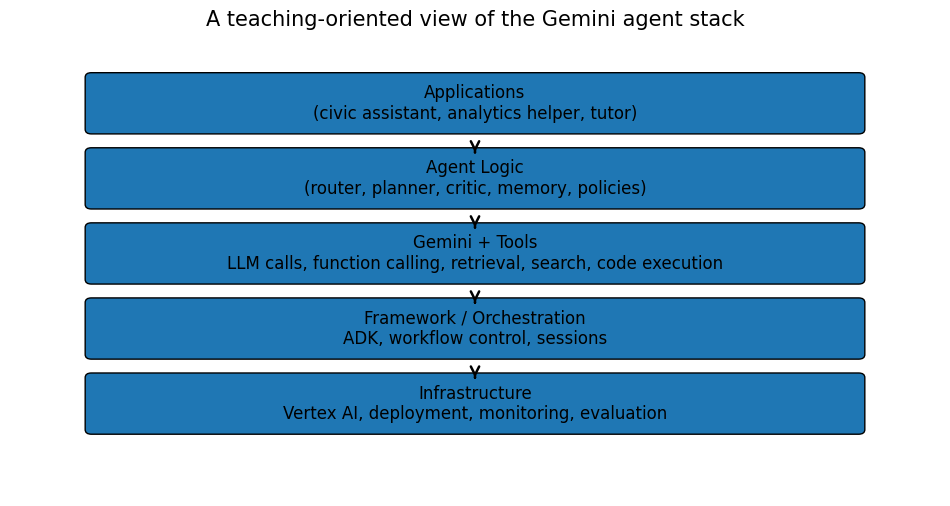

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis("off")

layers = [
    (1, 6.3, 10, 1.0, "Applications\n(civic assistant, analytics helper, tutor)"),
    (1, 5.0, 10, 1.0, "Agent Logic\n(router, planner, critic, memory, policies)"),
    (1, 3.7, 10, 1.0, "Gemini + Tools\nLLM calls, function calling, retrieval, search, code execution"),
    (1, 2.4, 10, 1.0, "Framework / Orchestration\nADK, workflow control, sessions"),
    (1, 1.1, 10, 1.0, "Infrastructure\nVertex AI, deployment, monitoring, evaluation")
]

for x, y, w, h, label in layers:
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03,rounding_size=0.08")
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=12)

for y1, y2 in [(6.0, 5.95), (4.7, 4.65), (3.4, 3.35), (2.1, 2.05)]:
    arrow = FancyArrowPatch((6, y1), (6, y2), arrowstyle="->", mutation_scale=15, lw=1.8)
    ax.add_patch(arrow)

plt.title("A learning-oriented view of the Gemini agent stack", fontsize=15)
plt.show()

## 🔄 From LLM app to agent: what changes?

The transition usually happens in stages.

| Stage | Typical behavior | Limitation |
|---|---|---|
| 1. Prompted LLM app | Single response from one prompt | No external action or verification |
| 2. Tool-using app | Calls APIs or functions | Still mostly linear |
| 3. Agentic workflow | Chooses next steps dynamically | More complexity to manage |
| 4. Multi-agent system | Specialized agents coordinate | Harder evaluation and debugging |
| 5. Production agent platform | Monitoring, memory, governance, deployment | Requires engineering discipline |

### Key insight

“Agent” is not a magic label.  
An agent is useful only when there is a meaningful **decision process** over actions, tools, or subgoals.

## Core AI/ML design patterns for agentified systems

Below are the patterns I recommend teaching first.

### 📐 1. Router pattern
A model classifies the request and chooses a path.

**Example:**  
Is the resident asking about waste, roads, licensing, childcare, or taxes?

### 📐 2. Retrieval + generation pattern
The system retrieves trusted documents before answering.

**Example:**  
Look up service pages from the City, Region, Province, or Federal government.

### 📐 3. Tool-calling pattern
The model decides when to call functions or APIs.

**Example:**  
Call `lookup_service_owner(service_name)` or `get_contact_info(jurisdiction, service)`.

### 📐 4. Planner-worker pattern
One component decomposes the task; others perform the work.

**Example:**  
Planner: “Identify service → find jurisdiction → gather next steps → draft answer.”

### 📐 5. Critique / verify pattern
A second pass checks the answer for confidence, grounding, and safety.

**Example:**  
Did the assistant cite the right jurisdiction? Did it overstate certainty?

### 📐 6. Memory / state pattern
The system uses persistent or session state.

**Example:**  
Remember that the resident already asked about their address and preferred language.

### 📐 7. Human-in-the-loop pattern
The workflow escalates uncertain cases.

**Example:**  
When multiple jurisdictions share responsibility, the assistant asks a clarifying question.

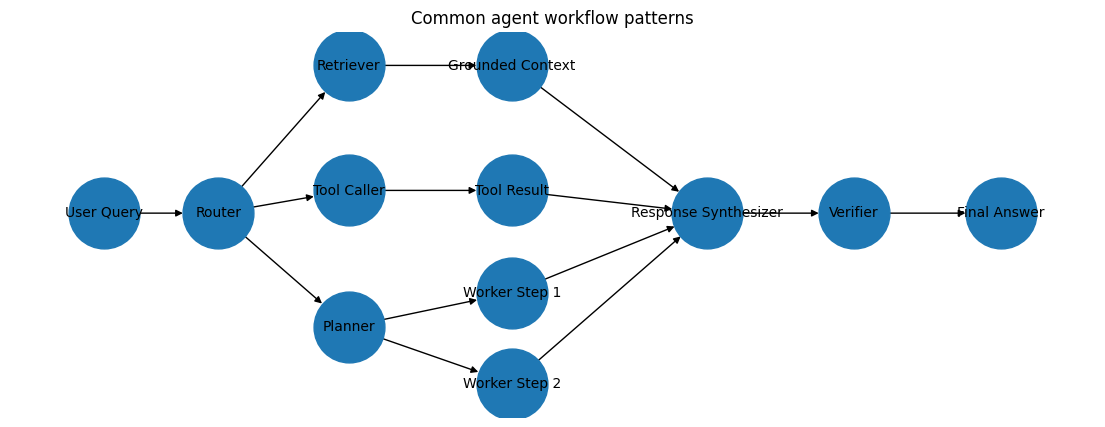

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
edges = [
    ("User Query", "Router"),
    ("Router", "Retriever"),
    ("Router", "Tool Caller"),
    ("Router", "Planner"),
    ("Retriever", "Grounded Context"),
    ("Tool Caller", "Tool Result"),
    ("Planner", "Worker Step 1"),
    ("Planner", "Worker Step 2"),
    ("Grounded Context", "Response Synthesizer"),
    ("Tool Result", "Response Synthesizer"),
    ("Worker Step 1", "Response Synthesizer"),
    ("Worker Step 2", "Response Synthesizer"),
    ("Response Synthesizer", "Verifier"),
    ("Verifier", "Final Answer"),
]
G.add_edges_from(edges)

pos = {
    "User Query": (0, 0),
    "Router": (1.4, 0),
    "Retriever": (3, 1.3),
    "Tool Caller": (3, 0.2),
    "Planner": (3, -1.0),
    "Grounded Context": (5, 1.3),
    "Tool Result": (5, 0.2),
    "Worker Step 1": (5, -0.7),
    "Worker Step 2": (5, -1.5),
    "Response Synthesizer": (7.4, 0),
    "Verifier": (9.2, 0),
    "Final Answer": (11.0, 0),
}

plt.figure(figsize=(14, 5))
nx.draw_networkx(G, pos=pos, with_labels=True, node_size=2600, font_size=10, arrows=True)
plt.title("Common agent workflow patterns")
plt.axis("off")
plt.show()

## 🛠 Minimal environment setup

The examples below use the **Google Gen AI SDK** from Python.

### Before running
You will need a Gemini API key. In a learning environment, it is often best to:

- Distribute setup instructions in advance,
- Use environment variables instead of hardcoding keys,
- 🚨🚨🚨 Warning: Never commit secrets to GitHub!!!

#### ❗Check out the `Google_Gemini_APIKEY` notebook for a tutorial on managing API keys.

In [ ]:
# NOTE: The following code checks for the presence of the GEMINI_API_KEY environment variable, which is 
# necessary for authenticating with the Gemini API. In practice, you should set this environment variable 
# in your shell or a .env file before running the notebook to ensure that the API calls work correctly.   
import os

# In practice, set this in your shell or a .env file.
# os.environ["GEMINI_API_KEY"] = "YOUR_KEY_HERE"

api_key_present = "GEMINI_API_KEY" in os.environ
print("GEMINI_API_KEY detected:", api_key_present)

In [1]:
!pip install -q google-genai

# NOTE: The following code securely prompts the user for their Google Gemini API key at runtime, which is 
# a best practice for handling sensitive information. This approach prevents hardcoding the API key in the 
# code and allows users to input it securely when needed. Make sure to run this code in an environment that 
# supports interactive input (like a Jupyter notebook or terminal).
import os
import getpass
from google import genai

# Securely prompt for the API key
print("Please enter your Google Gemini API Key:")
os.environ["GEMINI_API_KEY"] = getpass.getpass()

# Initialize the client
client = genai.Client()
print("\nGemini client initialized successfully! You are ready to build.")

Please enter your Google Gemini API Key:

Gemini client initialized successfully! You are ready to build.


## 1️⃣ First Gemini call

We start with the simplest possible interaction: a single model call.

This is **not yet** an agent.  
It is just a useful baseline.

In [2]:
from google import genai

# client = genai.Client()

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="In 4 bullet points, explain what makes an AI application agentic."
)

print(response.text)

An AI application is considered "agentic" when it moves beyond simply responding to prompts and actively takes initiative to achieve a broader objective. This involves:

*   **Possesses a Clearly Defined Objective or High-Level Goal:** Instead of just answering a question or generating a single piece of content, an agentic AI is given an overarching mission (e.g., "Plan my next vacation," "Research market trends for X," "Automate customer support for Y issue"). It understands and works towards this goal over multiple steps.
*   **Demonstrates Autonomy and Initiative:** Once given its goal, the AI application takes multiple sequential steps on its own, without requiring constant human prompting for each individual action. The user specifies *what* to achieve, not *how* to achieve it, leaving the planning and execution up to the agent.
*   **Engages in a Perception-Action Loop with Tool Use:** It can observe its environment (e.g., read emails, browse the web, interact with databases), in

### 👥 Discussion

Why begin here?

Because we need a baseline before complexity is added.  
A good pedagogical sequence is:

1. Single call,
2. Structured call,
3. Tool call,
4. Loop,
5. Multi-step workflow,
6. Evaluation.

That sequence makes debugging much easier.

## Adding structure: from free text to machine-usable outputs

Most real AI/ML systems should not stop at “nice text.”  
They need structured outputs that downstream code can consume.

For the civic assistant, a useful intermediate representation might be:

- `service`
- `jurisdiction`
- `confidence`
- `requires_clarification`
- `recommended_next_step`

The point is simple:

> LLMs are much easier to integrate when they produce typed, constrained outputs.

In [3]:
import json
from google.genai import types

schema = {
    "type": "OBJECT",
    "properties": {
        "service": {"type": "STRING"},
        "jurisdiction": {
            "type": "STRING",
            "enum": ["City", "Region", "Province", "Federal", "Unknown"]
        },
        "confidence": {"type": "NUMBER"},
        "requires_clarification": {"type": "BOOLEAN"},
        "recommended_next_step": {"type": "STRING"},
    },
    "required": [
        "service",
        "jurisdiction",
        "confidence",
        "requires_clarification",
        "recommended_next_step",
    ]
}

prompt = '''
Classify this resident question:
"Who do I contact about garbage pickup?"

Return only a structured response.
'''

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt,
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=schema,
    ),
)

parsed = json.loads(response.text)
parsed

{'service': 'Garbage Pickup',
 'jurisdiction': 'City',
 'confidence': 0.95,
 'requires_clarification': False,
 'recommended_next_step': "Provide contact information for the city's waste management department."}

## 🔧 Tool use: the first real step toward agentified behavior

Now we give the model access to an external function.

In production, that function might query:

- A municipal service registry,
- An open dataset,
- A search index,
- A CRM,
- A contact directory,
- A policy database.

For teaching, a Python function is enough.

### Important SDK note

In the current `google-genai` Python SDK, you do **not** pass a raw OpenAI-style function schema directly as `tools=[tool]`.

Instead, you wrap one or more function declarations inside:

```python
types.Tool(function_declarations=[...])
```

That distinction matters because the SDK validates `tools` as Gemini SDK tool objects or callables.

Reference: Google’s official function-calling guide.

In [4]:
SERVICE_OWNERSHIP = {
    "garbage pickup": {
        "jurisdiction": "Region",
        "contact": "Region of Waterloo waste services",
        "next_step": "Check your collection schedule and waste service page."
    },
    "childcare licensing": {
        "jurisdiction": "Province",
        "contact": "Ontario child care and early years services",
        "next_step": "Review provincial childcare information and program requirements."
    },
    "property tax billing": {
        "jurisdiction": "City",
        "contact": "City property tax office",
        "next_step": "Contact the city revenue or tax department."
    },
}

def lookup_service_owner(service_name: str):
    key = service_name.strip().lower()
    result = SERVICE_OWNERSHIP.get(key)
    if result is None:
        return {
            "jurisdiction": "Unknown",
            "contact": "Unknown",
            "next_step": "Escalate to a human or search trusted government sources."
        }
    return result

lookup_service_owner("garbage pickup")

{'jurisdiction': 'Region',
 'contact': 'Region of Waterloo waste services',
 'next_step': 'Check your collection schedule and waste service page.'}

In [5]:
tool_schema = {
    "name": "lookup_service_owner",
    "description": "Looks up which level of government owns a public service and suggests next steps.",
    "parameters": {
        "type": "object",
        "properties": {
            "service_name": {
                "type": "string",
                "description": "Name of the public service, for example garbage pickup or property tax billing."
            }
        },
        "required": ["service_name"]
    }
}

tools = [
    types.Tool(function_declarations=[tool_schema])
]

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents='A resident asks: "Who do I contact about garbage pickup?" Use the tool if helpful.',
    config=types.GenerateContentConfig(
        tools=tools
    ),
)

response.candidates[0].content.parts

[Part(
   function_call=FunctionCall(
     args={
       'service_name': 'garbage pickup'
     },
     name='lookup_service_owner'
   ),
   thought_signature=b'\n\xc5\x02\x01\xbe>\xf6\xfb|(\xf260\xa9#>\x8e\x15\xe7Aw\xffIr\x8d\xb3`\xde(\x8cf\xe6\xcbe\xcc\xea\xe5D\xfd\xbb\xb6\xe6\xba\x92\tUx\xf5X\xd2:%\x14\x08\xaeg\xfd\x18\xa0\x8d\xe5\xc4\xcc\x85Q\xa2\x98q\xbc\xc6\x10\n_\xf6\xc4fY%h\r\x9f\xaa\xb5\xa3\x9eR\xe8E\x01V\xef=b\xb9\xcc\x95\xcf...'
 )]

### 💡 Understanding Gemini Function Call Responses

What Each Piece Means

`Part(...)`

A Gemini response is composed of **one or more content parts**.  
Each part can represent different things, such as:

*   Plain text
*   A function call
*   Code
*   Other structured outputs

`function_call = FunctionCall(...)`

This indicates that **the model chose to invoke a tool** instead of directly answering the user’s question in natural language.

`name = 'lookup_service_owner'`

The model correctly selected **which tool** should be used based on the user’s request.

`args = {'service_name': 'garbage pickup'}`

The model extracted the **argument values** it wants to send to the tool.

Specifically, it identified:

*   **Parameter name:** `service_name`
*   **Parameter value:** `"garbage pickup"`

Plain‑English Interpretation

The model interpreted the resident’s request as:

```text
Tool to call: lookup_service_owner
Input: "garbage pickup"
```

`thought_signature = ...`

You can **ignore this field for teaching purposes**.

*   It is **internal metadata** related to the model’s reasoning process.
*   Students **do not need to parse or use it**.
*   It is not part of the application logic.

What the Model Is Actually Saying

Semantically, the model is saying:

> *“I think the next step is to call  
> `lookup_service_owner(service_name='garbage pickup')`.”*

What Has **Not** Happened Yet

At this point:

*   ✅ The model has **proposed** a function call
*   ❌ Your Python code has **not executed the tool**
*   ❌ No real lookup has happened
*   ❌ No external data has been retrieved

**Important:**  
The model has **only generated a structured suggestion**, not performed any real action.

✅ Key Teaching Point

This stage represents:

> **Tool selection and argument generation — *not* tool execution**

✅ Explaining the Full Flow

A clear way to teach the agent/tool workflow is:

1.  **User asks a question**
2.  **Model decides a tool is needed**
3.  **Model emits a structured function call**
4.  **Your application code executes the real function**
5.  **Your application sends the function result back to the model**
6.  **The model converts the result into a natural‑language answer**


In [6]:
# Step 1: Ask the model a question with tool access enabled.

question = 'A resident asks: "Who do I contact about garbage pickup?"'

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=question,
    config=types.GenerateContentConfig(tools=tools),
)

# Step 2: Inspect the returned parts and look for a function call.

parts = response.candidates[0].content.parts

for part in parts:
    if getattr(part, "function_call", None):
        print("Tool selected:", part.function_call.name)
        print("Arguments:", dict(part.function_call.args))
    elif getattr(part, "text", None):
        print("Model text:", part.text)

Tool selected: lookup_service_owner
Arguments: {'service_name': 'garbage pickup'}


### 📝 Execute the tool in application code

At this point, your Python application is in control.

The model has selected the tool and generated arguments, but **your code** must decide how to execute the function, validate inputs, log the call, handle errors, and possibly consult real data sources.

In a municipal assistant, this is where you would connect to curated service tables, open-data records, a search index, or official service directories.

In [7]:
# Step 3: Execute the selected tool manually.
# This keeps the architecture explicit for students.

function_calls = [p.function_call for p in parts if getattr(p, "function_call", None)]

if function_calls:
    call = function_calls[0]
    fn_name = call.name
    fn_args = dict(call.args)

    tool_result = lookup_service_owner(**fn_args)

    print("Executed tool:", fn_name)
    print("Tool result:", tool_result)
else:
    print("No function call was returned.")

Executed tool: lookup_service_owner
Tool result: {'jurisdiction': 'Region', 'contact': 'Region of Waterloo waste services', 'next_step': 'Check your collection schedule and waste service page.'}


### ➡️ Send the tool result back to Gemini

Now we return the tool output to the model so it can write a user-facing answer.

The model is no longer guessing from its own parametric knowledge alone. It is composing an answer using the external tool result your application supplied.

In [8]:
# Step 4: Send the tool result back to Gemini for answer synthesis.

if function_calls:
    followup = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[
            types.Content(
                role="user",
                parts=[types.Part(text=question)]
            ),
            response.candidates[0].content,
            types.Content(
                role="user",
                parts=[
                    types.Part.from_function_response(
                        name=fn_name,
                        response=tool_result
                    )
                ]
            ),
        ],
    )

    print(followup.text)

You should contact the Region of Waterloo waste services. You can check their collection schedule and waste service page for more information.


### 📌 Why this pattern matters

This four-step loop is the core of tool-using agent behavior:

- The model decides,
- The application acts,
- External state changes or data retrieval happens outside the model,
- The model then explains the result to the user.

Once you understand this loop, you are ready to move from “LLM application” to “agentified AI/ML application.”

## A simple single-agent architecture

The most teachable first agent is often **not** multi-agent.

A strong first architecture is:

1. Classify the question,
2. Retrieve or look up trusted information,
3. Synthesize an answer,
4. Verify whether the answer is grounded and actionable.

This is enough to learn most core concepts without adding unnecessary orchestration complexity.

In [9]:

def civic_agent_pipeline(question: str):
    # Step 1: extract a service label from the question
    extraction_prompt = f'''
    Extract the main public service being asked about.
    Return only the short service label.

    Question: {question}
    '''
    service = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=extraction_prompt
    ).text.strip().lower()

    # Step 2: use a local tool or registry
    lookup = lookup_service_owner(service)

    # Step 3: synthesize a final answer
    answer_prompt = f'''
    Resident question: {question}
    Interpreted service: {service}
    Lookup result: {lookup}

    Write a concise public-facing answer.
    State the likely jurisdiction, who to contact, and the next step.
    If certainty is limited, say so.
    '''
    answer = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=answer_prompt
    ).text

    return {
        "service": service,
        "lookup": lookup,
        "answer": answer,
    }

demo = civic_agent_pipeline("Who do I contact about garbage pickup?")
demo

{'service': 'garbage pickup',
 'lookup': {'jurisdiction': 'Region',
  'contact': 'Region of Waterloo waste services',
  'next_step': 'Check your collection schedule and waste service page.'},
 'answer': 'Garbage pickup is managed by the Region. Please contact the Region of Waterloo waste services and check your collection schedule and waste service page for details.'}

## 👍 Where retrieval fits in

For a real municipal assistant, a hardcoded dictionary is not enough.

We need retrieval over trusted sources such as:

- City of Kitchener service pages,
- Region of Waterloo service pages,
- Ontario service pages,
- Government of Canada service pages,
- open data or internal service registries.

That gives us a key design principle:

> **Use the model for interpretation and synthesis.  
> Use tools and retrieval for facts, records, and operational truth.**

This is one of the most important engineering lessons in agent design.

## 👍 How File Search changes the design

A modern Gemini-based application can use retrieval to ground its responses in indexed files or document collections.

That means the architecture can evolve from:

> resident question → LLM answer

to:

> resident question → retrieve relevant service sources → LLM grounded synthesis

In a teaching setting, this opens the door to discussing:

- Semantic retrieval,
- Chunking,
- Indexing,
- Citations,
- Grounding,
- Trust calibration,
- Evaluation of retrieval quality.

In [10]:

# Pseudocode for a retrieval-grounded pattern.
# This cell is for architecture reading, not immediate execution.

file_search_pseudocode = '''
1. Create a file search store
2. Upload municipal service documents
3. Query the model with the File Search tool attached
4. Ask the model to cite and summarize responsibility + next steps
'''
print(file_search_pseudocode)


1. Create a file search store
2. Upload municipal service documents
3. Query the model with the File Search tool attached
4. Ask the model to cite and summarize responsibility + next steps



## 🤖🤖 Multi‑Agent systems: when are they worth it?

Students often want to jump straight to “multi-agent.”

That is understandable, but premature complexity is a common mistake.

Use multiple agents only when there is a **clear division of labor**, for example:

- **Router agent**: classifies the request
- **Research agent**: gathers relevant service evidence
- **Policy agent**: checks wording and compliance constraints
- **Response agent**: drafts the final resident-friendly answer
- **Evaluator agent**: scores confidence and grounding

### 👍 Rule

If one well-designed agent with tools can do the job, start there first.

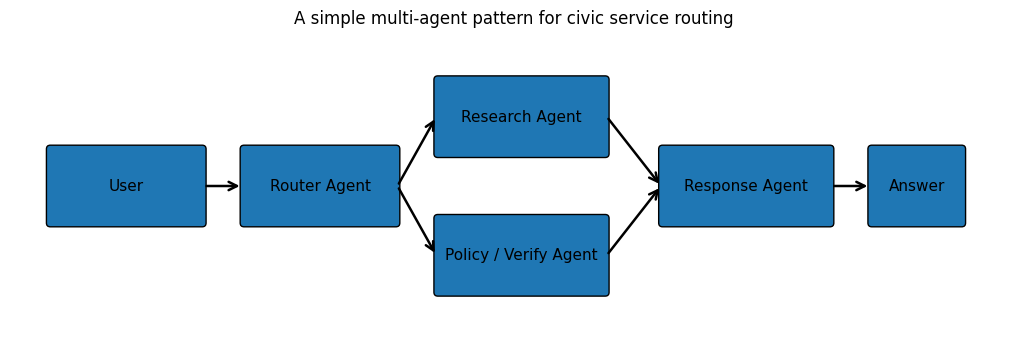

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis("off")

boxes = [
    (0.5, 1.5, 2.0, 1.0, "User"),
    (3.0, 1.5, 2.0, 1.0, "Router Agent"),
    (5.5, 2.4, 2.2, 1.0, "Research Agent"),
    (5.5, 0.6, 2.2, 1.0, "Policy / Verify Agent"),
    (8.4, 1.5, 2.2, 1.0, "Response Agent"),
    (11.1, 1.5, 1.2, 1.0, "Answer"),
]

for x, y, w, h, label in boxes:
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03,rounding_size=0.05")
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=11)

arrows = [
    ((2.5, 2.0), (3.0, 2.0)),
    ((5.0, 2.0), (5.5, 2.9)),
    ((5.0, 2.0), (5.5, 1.1)),
    ((7.7, 2.9), (8.4, 2.0)),
    ((7.7, 1.1), (8.4, 2.0)),
    ((10.6, 2.0), (11.1, 2.0)),
]
for start, end in arrows:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=15, lw=1.8))

plt.title("A simple multi-agent pattern for civic service routing")
plt.show()

## 💬 What ADK contributes

As agent workflows grow, handwritten orchestration becomes difficult to maintain.

A framework such as ADK helps students and teams think in software-engineering terms:

- agent definitions,
- instructions,
- tools,
- sessions,
- orchestration,
- testing,
- deployment paths.

That is especially useful when moving from notebook exploration to production-like architecture.

In [16]:
# Illustrative ADK-style pseudocode.
# Keep this as a conceptual bridge for students before a deeper ADK lab.

adk_example = '''
from google.adk import Agent
from google.adk.tools import google_search

research_agent = Agent(
    name="service_researcher",
    model="gemini-flash-latest",
    instruction="You research government services using trusted sources.",
    tools=[google_search],
)
'''
print(adk_example)


from google.adk import Agent
from google.adk.tools import google_search

research_agent = Agent(
    name="service_researcher",
    model="gemini-flash-latest",
    instruction="You research government services using trusted sources.",
    tools=[google_search],
)



## 📝Self-assessment

Agentic systems can look impressive while being unreliable.

For the civic assistant, evaluation should include at least:

- **Jurisdiction accuracy**  
  Did the system identify the correct level of government?

- **Grounding quality**  
  Was the answer supported by trustworthy sources?

- **Actionability**  
  Did the response give a clear next step?

- **Calibration**  
  Did the assistant express uncertainty when evidence was weak?

- **Safety and public communication quality**  
  Did the wording avoid overclaiming, ambiguity, or misleading advice?

### Suggested class exercise 🏋️ 

Ask students to build a 20-question benchmark with labels such as:

- service category
- true jurisdiction
- acceptable contact path
- expected clarifying question, if any

In [17]:
import pandas as pd

evaluation_stub = pd.DataFrame([
    {
        "question": "Who do I contact about garbage pickup?",
        "true_jurisdiction": "Region",
        "predicted_jurisdiction": None,
        "grounded": None,
        "actionable": None,
        "notes": "",
    },
    {
        "question": "Is childcare a city or provincial service?",
        "true_jurisdiction": "Province",
        "predicted_jurisdiction": None,
        "grounded": None,
        "actionable": None,
        "notes": "",
    },
])

evaluation_stub

,question,true_jurisdiction,predicted_jurisdiction,grounded,actionable,notes
0,Who do I contact about garbage pickup?,Region,None,None,None,
1,Is childcare a city or provincial service?,Province,None,None,None,


## 💥 Common failure modes in agentified systems

Students should learn these early.

### ☠️ Failure mode 1: hallucinated authority
The model sounds confident about the wrong jurisdiction.

### ☠️ Failure mode 2: tool misuse
The model calls a tool unnecessarily or with poor arguments.

### ☠️ Failure mode 3: retrieval mismatch
The retrieved passage is real but not relevant to the user’s exact question.

### ☠️ Failure mode 4: over-engineering
A multi-agent architecture is used where a single grounded workflow would be better.

### ☠️ Failure mode 5: poor state management
The system loses track of prior clarification, context, or user intent.

### ☠️ Failure mode 6: no evaluation harness
The application looks good in demos but performs inconsistently in practice.

## Connection to Day 2: the municipal challenge

The follow-up workshop challenge asks students to build:

> an AI-powered assistant that helps residents determine which level of government is responsible for a service and what to do next.

That challenge is ideal because it naturally requires:

- classification,
- retrieval,
- tool use,
- uncertainty handling,
- explainability,
- evaluation.

### A recommended first architecture for students

**Version 1**
- single agent,
- structured output,
- one retrieval source,
- one lookup tool,
- explicit confidence field.

**Version 2**
- add more sources,
- add clarifying questions,
- add verification step,
- add small evaluation set.

**Version 3**
- productionize workflow,
- package data and evaluation logic,
- convert components into a reproducible pipeline with DVC.

## 🔮 Looking Ahead: why DVC belongs after the agent lesson

At first glance, DVC may seem unrelated to AI agents. It is not.

Once students move beyond a demo, they need reproducibility for:

- indexed source data,
- evaluation datasets,
- prompt templates,
- schemas,
- pipeline stages,
- reports and metrics.

This turns the workshop into a broader lesson:

> **Agent design solves the interaction problem.  
> ML pipelines solve the reproducibility problem.**

That bridge is pedagogically powerful.

## 🤔 Reflection prompts

1. What is the smallest useful definition of an AI agent?
2. When should you prefer retrieval over memory?
3. When is a function call better than asking the model to answer directly?
4. What does a “grounded answer” mean in a civic context?
5. Why might a single-agent system outperform a multi-agent system on a student project?
6. What parts of this architecture should become DVC pipeline stages later?

## Suggested mini-exercises

### 🧠 Exercise A — Prompt to schema
Convert a free-text answer into a JSON schema with confidence and next-step fields.

### 🧠 Exercise B — Build one tool
Create a function for looking up service ownership from a curated service table.

### 🧠 Exercise C — Add a verifier
Create a second pass that checks whether the answer is grounded and appropriately cautious.

### 🧠 Exercise D — Prepare for Day 2
Write down the minimum datasets, APIs, or webpages needed for a real municipal prototype.